---
tags: [algorithm, simulation]
---

# Solving the Periodic Poisson Equation with QSVT in Qamomile

This notebook implements a QSVT-based algorithm for a small periodic Poisson problem. The implementation path is: build a [shift-based LCU block encoding](https://quantum-journal.org/papers/q-2025-06-04-1764/) in Qamomile, prepare the source vector as a quantum state, apply a QSVT inverse-polynomial sequence, transpile to Qiskit at the backend boundary, and compare the simulated solution with a classical pseudoinverse reference.

The examples are intentionally small because the result checks use exact `Operator` and `Statevector` simulation.


The next cell collects the packages used throughout the notebook. Qamomile describes the quantum kernels; Qiskit is used only at the backend boundary for circuit conversion and exact statevector/operator checks.


In [7]:
import math
import os
import warnings

import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.state_preparation import amplitude_encoding
from qamomile.qiskit import QiskitTranspiler
import qiskit
from qiskit.quantum_info import Operator, Statevector

## Background

We solve the finite-dimensional linear system

$$
A u = b,
$$

where `A` is the periodic finite-difference Laplacian and `b` is the sampled source term. This matches the discrete periodic Poisson structure shown in [Eq. (7)](https://quantum-journal.org/papers/q-2025-06-04-1764/): the second-difference stencil gives a tridiagonal matrix with two corner entries that wrap the first and last grid points together.

For `n` stored grid unknowns `u_0, ..., u_{n-1}`, periodic indexing means `u_{j+n}=u_j`. The entries `u_0` and `u_{n-1}` are neighboring unknowns across the periodic boundary, not the same stored degree of freedom. The parameter `h` is the grid spacing; in the code below, for an interval of length `L`, we use `h = L / (n + 1)` for the demonstration grid. With the sign convention in this notebook,

$$
(A u)_j = \frac{u_{j+1} - 2u_j + u_{j-1}}{h^2} = b_j,
\qquad j=0,\ldots,n-1.
$$

In matrix form this is

$$
\frac{1}{h^2}
\begin{pmatrix}
-2 & 1 & 0 & \cdots & 0 & 1 \\
1 & -2 & 1 & \cdots & 0 & 0 \\
0 & 1 & -2 & \ddots & \vdots & \vdots \\
\vdots & \ddots & \ddots & \ddots & 1 & 0 \\
0 & \cdots & 0 & 1 & -2 & 1 \\
1 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
\begin{pmatrix}
u_0\\
u_1\\
\vdots\\
u_{n-3}\\
u_{n-2}\\
u_{n-1}
\end{pmatrix}
=
\begin{pmatrix}
b_0\\
b_1\\
\vdots\\
b_{n-3}\\
b_{n-2}\\
b_{n-1}
\end{pmatrix}.
$$

Equivalently, using the cyclic shifts `S_+` and `S_-`,

$$
A_{1D} = \frac{1}{h^2}\left(-2I + S_+ + S_-\right).
$$

A periodic Laplacian has a constant-vector nullspace, so a periodic Poisson source must satisfy the compatibility condition `sum(b) = 0`. By periodic boundary conditions, flux leaving one side re-enters from the opposite side, so the boundary flux cancels. Equivalently, the discrete Laplacian has zero row sum, so only zero-mean right-hand sides are in its range.


## Problem Settings

We first build the 1D finite-difference matrix `A` explicitly with `NumPy`. This gives a concrete reference matrix for later checks: after restoring the LCU scale factor, the leading block of the Qamomile block encoding should match this classical periodic Poisson matrix.

The source vector is also projected to zero mean so that it satisfies the periodic Poisson compatibility condition. We use the corresponding `NumPy` pseudoinverse solution only as a reference for the final QSVT result.


In [25]:
def build_1d_periodic_A_b(n, L=1.0, f=None):
    """Build the 1D periodic finite-difference Laplacian and source vector."""
    if n & (n - 1) != 0:
        raise ValueError("n must be a power of two for the shift encoding.")

    h = L / (n + 1)
    x = np.arange(1, n + 1) * h

    A = np.zeros((n, n), dtype=float)
    for i in range(n):
        A[i, i] = -2.0
        A[i, (i + 1) % n] = 1.0
        A[i, (i - 1) % n] = 1.0
    A = A / h**2

    b = np.zeros(n, dtype=float) if f is None else np.array([f(xi) for xi in x], dtype=float)
    return A, b, x, h


def normalize_state(v):
    """Return a real vector normalized for amplitude encoding."""
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("Cannot amplitude-encode the zero vector.")
    return v / norm


def project_periodic_rhs(b):
    """Project a periodic Poisson RHS onto the range of the Laplacian."""
    b = np.asarray(b, dtype=float)
    return b - np.mean(b)


def cyclic_shift_matrices(n):
    """Return S_plus and S_minus for periodic indexing."""
    S_plus = np.zeros((n, n), dtype=int)
    S_minus = np.zeros((n, n), dtype=int)
    for j in range(n):
        S_plus[j, (j + 1) % n] = 1
        S_minus[j, (j - 1) % n] = 1
    return S_plus, S_minus


def fidelity(u, v):
    """Compute squared overlap between two solution vectors."""
    u = np.asarray(u, dtype=complex)
    v = np.asarray(v, dtype=complex)
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    return abs(np.vdot(u, v)) ** 2


def align_global_phase(actual, target):
    """Return actual multiplied by the phase that best aligns it with target."""
    inner = np.vdot(actual, target)
    if abs(inner) < 1e-14:
        return actual
    return actual * inner / abs(inner)


n_1d = 8
f_1d = lambda x: np.sin(np.pi * x)
A1, raw_b1, x1, h1 = build_1d_periodic_A_b(n_1d, f=f_1d)
b1 = project_periodic_rhs(raw_b1)
u1 = np.linalg.pinv(A1) @ b1
normalized_b1 = normalize_state(b1)


S_plus_1d, S_minus_1d = cyclic_shift_matrices(n_1d)
print("S+ for the 1D demo:")
print(S_plus_1d)
print("S- for the 1D demo:")
print(S_minus_1d)
print("Unscaled periodic stencil h^2 A:")
print(np.round(h1**2 * A1).astype(int))


S+ for the 1D demo:
[[0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]]
S- for the 1D demo:
[[0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]]
Unscaled periodic stencil h^2 A:
[[-2  1  0  0  0  0  0  1]
 [ 1 -2  1  0  0  0  0  0]
 [ 0  1 -2  1  0  0  0  0]
 [ 0  0  1 -2  1  0  0  0]
 [ 0  0  0  1 -2  1  0  0]
 [ 0  0  0  0  1 -2  1  0]
 [ 0  0  0  0  0  1 -2  1]
 [ 1  0  0  0  0  0  1 -2]]


## Shift-Based Block Encoding

The 1D periodic Laplacian can be written as a linear combination of `I`, `S_+`, and `S_-`. The LCU circuit uses signal qubits to select the identity and cyclic shifts, so the leading block is proportional to `A_1D`.

The shift routine below names the two cyclic shifts directly in Qamomile: `qmc.modular_increment` implements `S_+`, sending `|j>` to `|j+1 mod 2^n>`, and `qmc.modular_decrement` implements `S_-`, sending `|j>` to `|j-1 mod 2^n>`. These controlled shifts are the primitive ingredients of the Poisson LCU block encoding.


In [9]:
import qamomile.circuit as qmc

# @qmc.qkernel
# def apply_controlled_shift_plus_on_q(
#     q: qmc.Vector[qmc.Qubit],
#     control_index: qmc.UInt,
#     num_system: qmc.UInt,
# ) -> qmc.Vector[qmc.Qubit]:
#     """Apply controlled |j> -> |j + 1 mod 2^num_system.

#     Layout:
#       q[0:num_system] = system
#       q[control_index] = external control
#     """
#     for k in qmc.range(num_system):
#         target_index = num_system - 1 - k

#         # Controls are:
#         #   q[control_index] and q[0:target_index]
#         #
#         # Number of controls:
#         #   1 external control + target_index prefix controls
#         mcx = qmc.control(qmc.x, num_controls=target_index + 1)

#         q[control_index], q[0:target_index], q[target_index] = mcx(
#             q[control_index],
#             q[0:target_index],
#             q[target_index],
#         )

#     return q

# @qmc.qkernel
# def apply_controlled_shift_minus_on_q(
#     q: qmc.Vector[qmc.Qubit],
#     control_index: qmc.UInt,
#     num_system: qmc.UInt,
# ) -> qmc.Vector[qmc.Qubit]:
#     """Apply controlled |j> -> |j - 1 mod 2^num_system.

#     Layout:
#       q[0:num_system] = system
#       q[control_index] = external control
#     """
#     for target_index in qmc.range(num_system):
#         mcx = qmc.control(qmc.x, num_controls=target_index + 1)

#         q[control_index], q[0:target_index], q[target_index] = mcx(
#             q[control_index],
#             q[0:target_index],
#             q[target_index],
#         )

#     return q

@qmc.qkernel
def apply_1d_poisson_block_encoding_on_q(
    q: qmc.Vector[qmc.Qubit],
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Forward 1D periodic Poisson LCU block encoding.

    Layout:
      q[0:num_system]   = system register
      q[num_system]     = signal[0], controls S-
      q[num_system + 1] = signal[1], controls S+
    """
    signal_0 = num_system
    signal_1 = num_system + 1
    
    controlled_increment = qmc.control(
        qmc.modular_increment,
        num_controls=1,
    )
    controlled_decrement = qmc.control(
        qmc.modular_decrement,
        num_controls=1,
    )
    # PREPARE signal qubits.
    q[signal_0] = qmc.h(q[signal_0])
    q[signal_1] = qmc.h(q[signal_1])

    q[signal_0] = qmc.z(q[signal_0])
    q[signal_1] = qmc.z(q[signal_1])

    # Apply S- controlled on signal_0 == 0.
    q[signal_0] = qmc.x(q[signal_0])
    # q = apply_controlled_shift_minus_on_q(
    #     q,
    #     signal_0,
    #     num_system,
    # )
    q[signal_0], q[0:num_system] = controlled_decrement(
        q[signal_0],
        q[0:num_system],
    )
    q[signal_0] = qmc.x(q[signal_0])
    
    # Apply S+ controlled on signal_1 == 1.
    # q = apply_controlled_shift_plus_on_q(
    #     q,
    #     signal_1,
    #     num_system,
    # )
    q[signal_1], q[0:num_system] = controlled_increment(
        q[signal_1],
        q[0:num_system],
    )

    # UNPREPARE signal qubits.
    q[signal_0] = qmc.h(q[signal_0])
    q[signal_1] = qmc.h(q[signal_1])

    return q


@qmc.qkernel
def apply_1d_poisson_block_encoding_inverse_on_q(
    q: qmc.Vector[qmc.Qubit],
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Inverse 1D periodic Poisson LCU block encoding."""
    q = qmc.inverse(apply_1d_poisson_block_encoding_on_q)(
        q,
        num_system,
    )

    return q


@qmc.qkernel
def block_encoding_kernel_1d(
    total_qubits: qmc.UInt,
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(total_qubits, name="q")

    q = apply_1d_poisson_block_encoding_on_q(
        q,
        num_system,
    )

    return qmc.measure(q)

## Result: 1D Block-Encoding Check

Before using QSVT, we check the emitted block encoding. The leading block of the circuit should reproduce the 1D periodic matrix after restoring the LCU scale factor. This exact check confirms that the primitive shift construction encodes $A_{1D}$.

The Qamomile documentation pattern is to define measured kernels, convert them with `transpiler.to_circuit(...)`, and remove final measurements only for exact `Operator` or `Statevector` inspection. We use that pattern here.


In [22]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

def operator_of(kernel: qmc.QKernel, **bindings) -> np.ndarray:
    """Convert a measured Qamomile kernel to an exact unitary matrix."""
    qc = transpiler.to_circuit(kernel, bindings=bindings or None)
    return Operator(
        qc.remove_final_measurements(inplace=False)
    ).data


1D encoding matches target: True
1D max abs error: 1.9895196601282805e-13


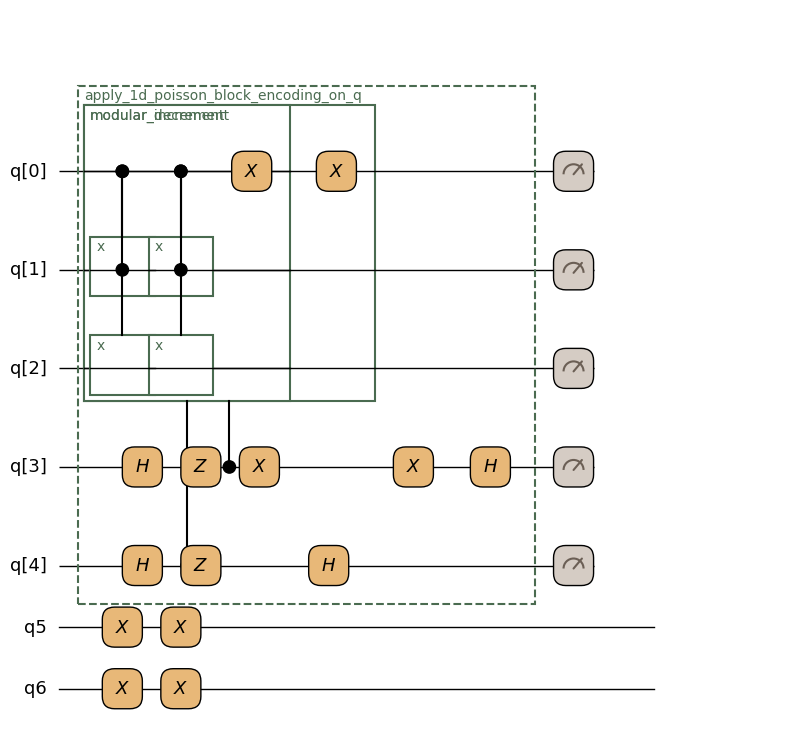

In [23]:
block_encoding_bindings_1d = {
    "num_system": int(np.log2(n_1d)),
    "total_qubits": int(np.log2(n_1d)) + 2,
}

full_op_1d = operator_of(block_encoding_kernel_1d, **block_encoding_bindings_1d)
encoded_A1 = full_op_1d[:n_1d, :n_1d].real * 4.0 / h1**2  #Eq 8a

print("1D encoding matches target:", np.allclose(encoded_A1, A1, atol=1e-8))
print("1D max abs error:", np.max(np.abs(encoded_A1 - A1)))

block_encoding_kernel_1d.draw(fold_loops=False, inline=True, **block_encoding_bindings_1d)


## Implementation: Möttönen Amplitude Encoding

The source vector is loaded with Qamomile's built-in [Möttönen Amplitude Encoding](https://jij-inc-qamomile.readthedocs-hosted.com/latest/en/algorithm/mottonen-amplitude-encoding/) helper, `amplitude_encoding(...)`. For real amplitudes this emits an `RY` stage with a Gray-code CNOT walk. We first inspect the standalone preparation circuit before using it inside QSVT.


In [12]:
def _check_power_of_two(length):
    """Validate that a state vector can be indexed by qubits."""
    if length <= 0 or length & (length - 1):
        raise ValueError("State-vector length must be a positive power of two.")


def make_state_preparation_kernel(amplitudes):
    """Build a small kernel that prepares the normalized source state."""
    amplitudes = normalize_state(amplitudes)
    num_system = int(np.log2(len(amplitudes)))

    @qmc.qkernel
    def state_preparation_kernel() -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(num_system, name="b")
        q = amplitude_encoding(q, amplitudes)
        return qmc.measure(q)

    return state_preparation_kernel


Möttönen preparation matches b: True
max abs error: 1.1102230246251565e-16


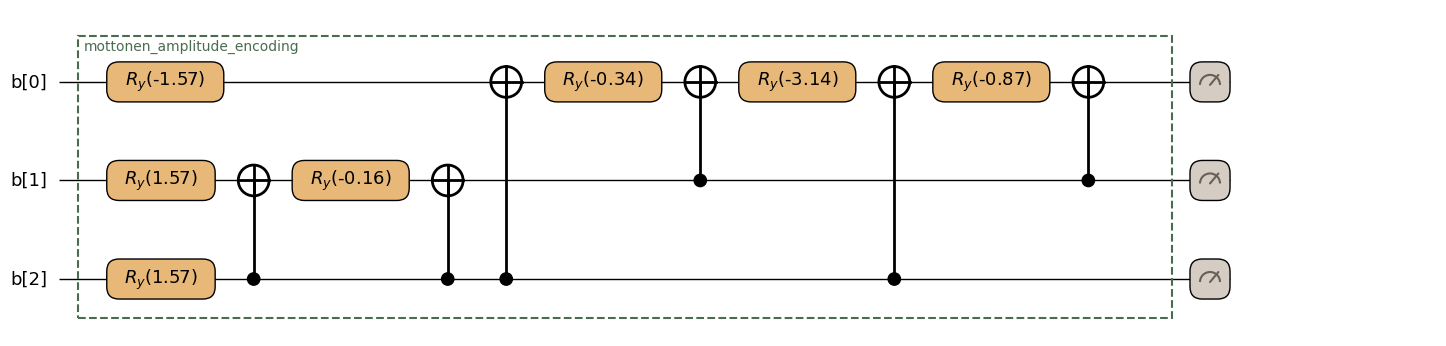

In [13]:
def statevector_of(kernel: qmc.QKernel, **bindings) -> np.ndarray:
    """Run *kernel* through Qiskit's statevector simulator and return the data."""
    qc = transpiler.to_circuit(kernel, bindings=bindings or None)
    return Statevector.from_instruction(
        qc.remove_final_measurements(inplace=False)
    ).data

prep_kernel = make_state_preparation_kernel(normalized_b1)

prepared_state = statevector_of(prep_kernel)
prepared_state = align_global_phase(prepared_state, normalized_b1)

print("Möttönen preparation matches b:", np.allclose(prepared_state.real, normalized_b1, atol=1e-8))
print("max abs error:", np.max(np.abs(prepared_state.real - normalized_b1)))
prep_kernel.draw(fold_loops=False, expand_composite=True)


## QSVT Inversion

[QSVT](https://dl.acm.org/doi/abs/10.1145/3313276.3316366) applies a polynomial transformation to the leading block of a block encoding. Here the target polynomial approximates `1/x`, so applying QSVT to the Poisson block encoding prepares a state proportional to the inverse or pseudoinverse solution.

Each QSVT step alternates the block encoding with a projector phase with $\phi$; the next cells explain how these phase angles are obtained.


In [14]:
# ============================================================
# Classical helpers
# ============================================================

def normalize_state(vec):
    """Return a normalized real vector for state preparation."""
    vec = np.asarray(vec, dtype=float)
    norm = np.linalg.norm(vec)
    if norm == 0:
        raise ValueError("State vector must not be zero.")
    return vec / norm


def _check_power_of_two(n: int):
    """Ensure the encoded dimension fits an integer number of qubits."""
    if n <= 0 or (n & (n - 1)) != 0:
        raise ValueError("Length must be a positive power of two.")


# ============================================================
# Open-projector phase for a signal register
# ============================================================
@qmc.qkernel
def apply_controlled_minus_ZPi_on_q(
    q: qmc.Vector[qmc.Qubit],
    control_qubit: qmc.UInt,
    signal_start: qmc.UInt,
    num_signal: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Apply controlled(-Z_Pi).

    Pi = |00...0><00...0| on the signal register.

    -Z_Pi = X^n MCZ X^n

    It gives -1 only when the signal register is |00...0>.
    The operation is controlled by control_qubit.
    """

    target = signal_start + num_signal - 1
    controls_start = signal_start
    controls_stop = signal_start + num_signal - 1

    # Map |00...0> -> |11...1>
    for offset in qmc.range(num_signal):
        q[signal_start + offset] = qmc.x(
            q[signal_start + offset]
        )

    # Controlled MCZ.
    # Controls are:
    #   control_qubit
    #   signal_start, ..., signal_start + num_signal - 2
    # Target is:
    #   signal_start + num_signal - 1
    mcz = qmc.control(
        qmc.z,
        num_controls=num_signal,
    )

    q[control_qubit], q[controls_start:controls_stop], q[target] = mcz(
        q[control_qubit],
        q[controls_start:controls_stop],
        q[target],
    )

    # Map back
    for offset in qmc.range(num_signal):
        q[signal_start + offset] = qmc.x(
            q[signal_start + offset]
        )

    return q


@qmc.qkernel
def apply_CPi_NOT_on_q(
    q: qmc.Vector[qmc.Qubit],
    aux_qubit: qmc.UInt,
    signal_start: qmc.UInt,
    num_signal: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Apply C_Pi NOT following Figure 13.4.

    The aux qubit is flipped iff the signal register is |00...0>.
    """

    q[aux_qubit] = qmc.h(q[aux_qubit])

    q = apply_controlled_minus_ZPi_on_q(
        q,
        aux_qubit,
        signal_start,
        num_signal,
    )

    q[aux_qubit] = qmc.h(q[aux_qubit])

    return q


@qmc.qkernel
def apply_RPi_figure_13_4_on_q(
    q: qmc.Vector[qmc.Qubit],
    aux_qubit: qmc.UInt,
    signal_start: qmc.UInt,
    num_signal: qmc.UInt,
    two_phi: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    """Apply R_Pi(phi) = exp(i phi (2 Pi - I)).

    The aux qubit must start in |0>.

    This implements:

        |00...0>   -> e^{+i phi}
        all others -> e^{-i phi}

    on the signal register.
    """

    q = apply_CPi_NOT_on_q(
        q,
        aux_qubit,
        signal_start,
        num_signal,
    )

    # RZ(2 phi) = exp(-i phi Z)
    # |0> -> e^{-i phi}|0>
    # |1> -> e^{+i phi}|1>
    q[aux_qubit] = qmc.rz(
        q[aux_qubit],
        two_phi,
    )

    q = apply_CPi_NOT_on_q(
        q,
        aux_qubit,
        signal_start,
        num_signal,
    )

    return q


# ============================================================
# QSVT sequence factory
# ============================================================

def make_qsvt_poisson_kernel_1d(grid_n, normalized_b, num_phases, num_signal=2):
    """Create the 1D Poisson QSVT kernel with a fixed phase count."""
    normalized_b = normalize_state(normalized_b)

    if num_phases <= 0:
        raise ValueError("num_phases must be positive.")

    expected_len = grid_n
    _check_power_of_two(expected_len)

    num_system = int(np.log2(expected_len))

    # Extra ancilla for Figure 13.4.
    rpi_aux = num_system + num_signal 
    total_qubits = num_system + num_signal + 1

    has_even_tail = (num_phases % 2 == 0)

    if len(normalized_b) != expected_len:
        raise ValueError(
            f"Expected len(normalized_b) == {expected_len}, "
            f"got {len(normalized_b)}."
        )

    if has_even_tail:

        @qmc.qkernel
        def qsvt_poisson_kernel_1d(
            theta: qmc.Vector[qmc.Float],
            half_theta: qmc.Vector[qmc.Float],
            neg_half_theta: qmc.Vector[qmc.Float],
            num_pairs: qmc.UInt,
        ) -> qmc.Vector[qmc.Bit]:
            q = qmc.qubit_array(total_qubits, name="q")

            q[0:num_system] = amplitude_encoding(
                q[0:num_system],
                normalized_b,
            )

            # rpi_aux is already |0>, as required by Figure 13.4.

            for pair in qmc.range(num_pairs):
                even_i = pair + pair
                odd_i = even_i + 1

                # two_phi = 2 phi
                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[even_i] + neg_half_theta[even_i],
                )

                q = apply_1d_poisson_block_encoding_on_q(
                    q,
                    num_system,
                )

                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[odd_i] + neg_half_theta[odd_i],
                )

                q = qmc.inverse(apply_1d_poisson_block_encoding_on_q)(
                    q,
                    num_system,
                )

            tail_i = num_pairs + num_pairs
            final_i = tail_i + 1

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[tail_i] + neg_half_theta[tail_i],
            )

            q = apply_1d_poisson_block_encoding_on_q(
                q,
                num_system,
            )

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[final_i] + neg_half_theta[final_i],
            )

            return qmc.measure(q)

    else:

        @qmc.qkernel
        def qsvt_poisson_kernel_1d(
            theta: qmc.Vector[qmc.Float],
            half_theta: qmc.Vector[qmc.Float],
            neg_half_theta: qmc.Vector[qmc.Float],
            num_pairs: qmc.UInt,
        ) -> qmc.Vector[qmc.Bit]:
            q = qmc.qubit_array(total_qubits, name="q")

            q[0:num_system] = amplitude_encoding(
                q[0:num_system],
                normalized_b,
            )

            # rpi_aux is already |0>.

            for pair in qmc.range(num_pairs):
                even_i = pair + pair
                odd_i = even_i + 1

                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[even_i] + neg_half_theta[even_i],
                )

                q = apply_1d_poisson_block_encoding_on_q(
                    q,
                    num_system,
                )

                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[odd_i] + neg_half_theta[odd_i],
                )

                q = qmc.inverse(apply_1d_poisson_block_encoding_on_q)(
                    q,
                    num_system,
                )

            final_i = num_pairs + num_pairs

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[final_i] + neg_half_theta[final_i],
            )

            return qmc.measure(q)

    return qsvt_poisson_kernel_1d


The next cell generates the phase sequence for the inverse-polynomial transformation. We use `pyqsp` to approximate `1/x`, convert the QSP phases to the QSVT convention used by the kernel, and bind those angles later when converting the Qamomile kernel to Qiskit.


In [15]:
def convert_qsp_to_qsvt(phi_prime):
    """Convert pyqsp Wx phases to the QSVT convention used below."""
    phi_prime = np.array(phi_prime, dtype=float)
    d = len(phi_prime) - 1
    phi = np.zeros_like(phi_prime)

    phi[0] = phi_prime[0] + (2 * d - 1) * np.pi / 4
    for k in range(1, d):
        phi[k] = phi_prime[k] - np.pi / 2
    phi[d] = phi_prime[d] - np.pi / 4

    return (phi + np.pi) % (2 * np.pi) - np.pi


def qsvt_inverse_phases(kappa=10, epsilon=0.1, tolerance=1e-5):
    """Generate phases for a bounded polynomial approximation to 1/x."""
    try:
        from pyqsp import angle_sequence
        from pyqsp import poly as pyqsp_poly
    except (ModuleNotFoundError, ImportError) as exc:
        if os.environ.get("QAMOMILE_DOCS_TEST") == "1":
            print("pyqsp is not installed; using a short docs-test phase sequence.")
            return np.array([np.pi / 4, 0.0, -np.pi / 4]), 1.0
        raise ModuleNotFoundError(
            "pyqsp is required for this tutorial cell. Install it with `pip install pyqsp`."
        ) from exc

    poly = pyqsp_poly.PolyOneOverX()
    pcoefs, scale = poly.generate(
        kappa=kappa,
        epsilon=epsilon,
        return_coef=True,
        ensure_bounded=True,
        return_scale=True,
    )
    phi_wx = angle_sequence.QuantumSignalProcessingPhases(
        pcoefs,
        signal_operator="Wx",
        tolerance=tolerance,
    )
    return convert_qsp_to_qsvt(phi_wx), scale


phi_qsvt, inverse_scale = qsvt_inverse_phases(kappa=10, epsilon=0.1)
print("Number of QSVT phases:", len(phi_qsvt))
print("Polynomial scale returned by pyqsp:", inverse_scale)


b=460, j0=67
[PolyOneOverX] minimum [-13.69663504] is at [-0.05227402]: normalizing
[PolyOneOverX] bounding to 0.9
Number of QSVT phases: 920
Polynomial scale returned by pyqsp: [0.06570957]


## Implementation: Solving the 1D Poisson Equation with QSVT

We now combine the Qamomile components for the 1D algorithm: source-state preparation, the shift-based Poisson block encoding, and the QSVT projector phases. A short three-phase circuit is drawn first so the kernel structure can be inspected without rendering the full phase sequence.


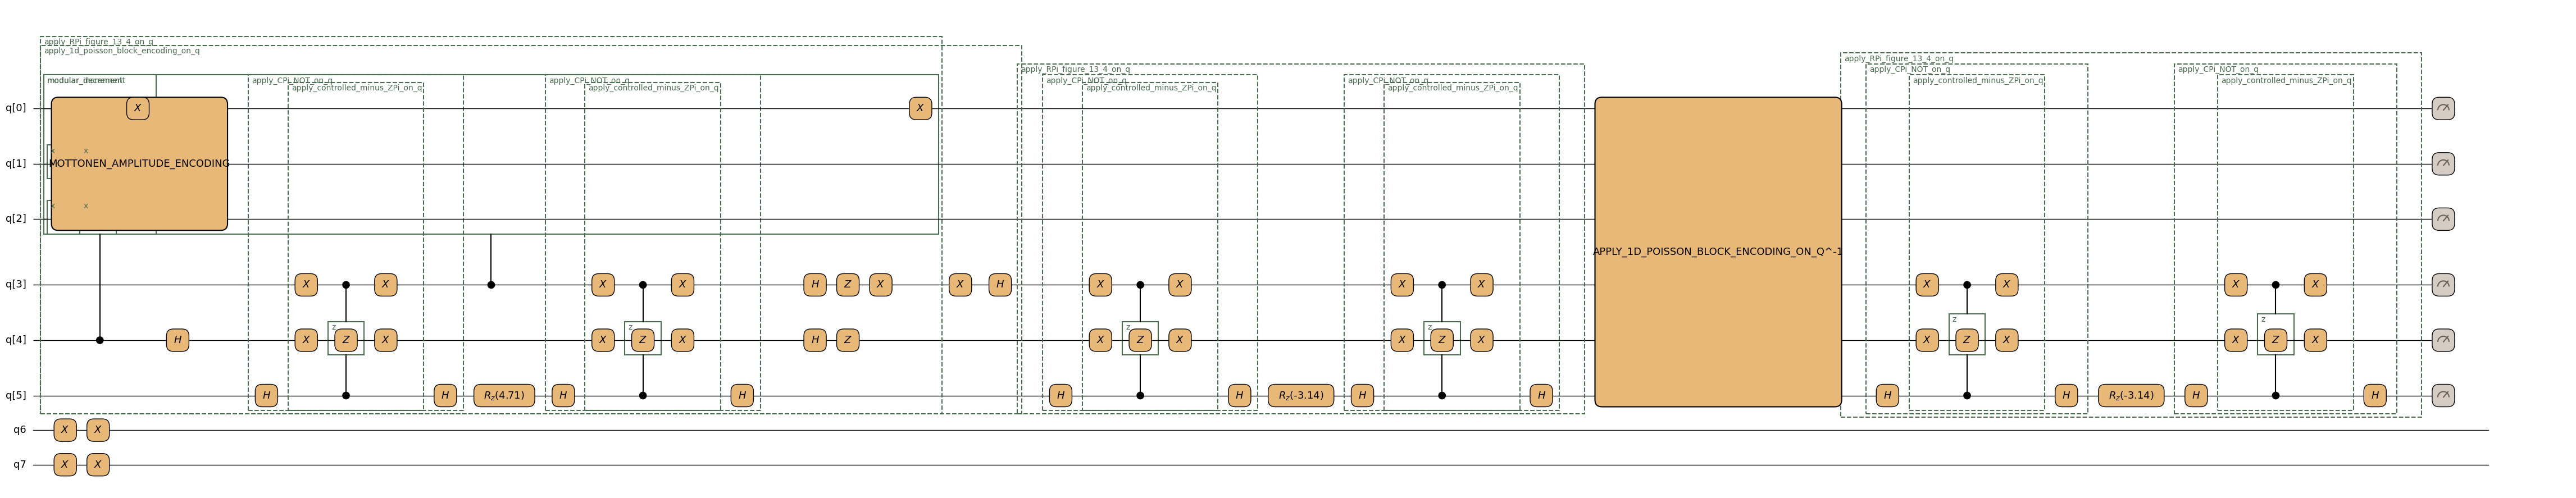

In [16]:
# ============================================================
# Short PoC draw: only first 3 QSVT phases
# ============================================================

poc_num_phases = 3
phi_qsvt_poc = np.asarray(phi_qsvt[:poc_num_phases], dtype=float)
theta_qsvt_poc = -2.0 * phi_qsvt_poc
poc_num_pairs = (poc_num_phases - 1) // 2

qsvt_kernel_1d_poc = make_qsvt_poisson_kernel_1d(
    n_1d,
    normalized_b1,
    poc_num_phases,
    num_signal=2,
)

qsvt_poc_bindings = {
    "theta": theta_qsvt_poc.tolist(),
    "half_theta": (0.5 * theta_qsvt_poc).tolist(),
    "neg_half_theta": (-0.5 * theta_qsvt_poc).tolist(),
    "num_pairs": poc_num_pairs,
}

qsvt_kernel_1d_poc.draw(
    fold_loops=False,
    inline=True,
    **qsvt_poc_bindings,
)


In [17]:
# ============================================================
# Full QSVT circuit: transpile to Qiskit
# ============================================================
# The projector kernel is parameterized by theta = -2 phi.
theta_qsvt = -2.0 * np.asarray(phi_qsvt, dtype=float)

# Pair loop consumes two phases per iteration; even phase counts need a tail.
full_num_pairs = (
    (len(phi_qsvt) - 2) // 2
    if len(phi_qsvt) % 2 == 0
    else (len(phi_qsvt) - 1) // 2
)

qsvt_bindings = {
    "theta": theta_qsvt.tolist(),
    "half_theta": (0.5 * theta_qsvt).tolist(),       # = -phi
    "neg_half_theta": (-0.5 * theta_qsvt).tolist(),  # = +phi
    "num_pairs": full_num_pairs,
}


qsvt_kernel_1d = make_qsvt_poisson_kernel_1d(
    n_1d,
    normalized_b1,
    len(phi_qsvt),
    num_signal=2,
)

qsvt_circuit_1d = transpiler.to_circuit(
    qsvt_kernel_1d,
    bindings=qsvt_bindings,
).remove_final_measurements(inplace=False)


Now we simulate that circuit and compares the recovered vector with the classical pseudoinverse solution.


In [18]:
psi_1d = Statevector.from_instruction(qsvt_circuit_1d).data
c1 = np.real(psi_1d[:A1.shape[0]])
Ac1 = A1 @ c1
alpha_1d = (Ac1 @ b1) / (Ac1 @ Ac1)
computed_u1 = alpha_1d * c1
residual_1d = np.linalg.norm(A1 @ computed_u1 - b1)

print("Computed u:", computed_u1)
print("Classical u:", u1)
print("fidelity:", fidelity(computed_u1, u1))
print("max abs error:", np.max(np.abs(computed_u1 - u1)))

Computed u: [ 0.0069216   0.00239196 -0.00295377 -0.00635978 -0.00635978 -0.00295377
  0.00239196  0.0069216 ]
Classical u: [ 0.00692158  0.00239208 -0.00295376 -0.0063599  -0.0063599  -0.00295376
  0.00239208  0.00692158]
fidelity: 0.999999999808626
max abs error: 1.1719198622422641e-07


Before moving to the 2D case, we record a small resource summary for the Qamomile kernel and the emitted Qiskit circuit. The helper below keeps generated shift subcircuits grouped together so the gate-count output stays readable.


In [20]:
def summarized_gate_counts(circuit):
    """Compact Qiskit count_ops output by grouping generated subcircuit names."""
    summary = {}
    for name, count in circuit.count_ops().items():
        key = "shift/subcircuit" if "circuit" in name else name
        summary[key] = summary.get(key, 0) + count
    return summary


def print_resource_estimate(label, kernel, qiskit_circuit, bindings=None):
    """Show Qamomile's logical estimate and the emitted Qiskit circuit size."""
    print(f"{label} Qamomile resource estimate:")
    print(kernel.estimate_resources(bindings=bindings).simplify())
    print(f"{label} Qiskit resource estimate:")
    print("  Qubits:", qiskit_circuit.num_qubits)
    print("  Depth:", qiskit_circuit.depth())
    print("  Gate counts:", summarized_gate_counts(qiskit_circuit))


print_resource_estimate("1D QSVT", qsvt_kernel_1d, qsvt_circuit_1d, qsvt_bindings)


1D QSVT Qamomile resource estimate:
Resource Estimate:
  Qubits: 6
  Gates:
    Total: 23003
    Single-qubit: 19319
    Two-qubit: 1844
    Multi-qubit: 1840
    T gates: 0
    Clifford gates: 18398
    Rotation gates: 927
1D QSVT Qiskit resource estimate:
  Qubits: 6
  Depth: 9660
  Gate counts: {'x': 8280, 'h': 5520, 'rz': 920, 'z': 920, 'ry': 7, 'cx': 6, 'shift/subcircuit': 3219}


## Extension to the 2D Poisson Equation

For the 2D case, we use the same workflow as the 1D case: build the periodic Poisson block encoding, verify its leading block, apply the QSVT inverse-polynomial sequence, and compare with the classical pseudoinverse solution. The 2D matrix is the Kronecker sum

$$
A_{2D} = A_{1D} \otimes I + I \otimes A_{1D}.
$$

The block encoding reuses Qamomile's `qmc.modular_increment` and `qmc.modular_decrement` as controlled cyclic shifts. In 2D, the system register is split into an x-register and a y-register, representing the two grid coordinates; an additional direction qubit selects which coordinate register receives the shift.


In [35]:
def build_2d_periodic_A_b(n, L=1.0, f=None):
    """Build the 2D periodic finite-difference Laplacian and source vector."""
    A1, _, x, h = build_1d_periodic_A_b(n, L=L)
    I = np.eye(n)
    A2 = np.kron(A1, I) + np.kron(I, A1)

    X, Y = np.meshgrid(x, x)
    if f is None:
        b2 = np.zeros(n * n, dtype=float)
    else:
        b2 = np.asarray(f(X, Y), dtype=float).reshape(-1)
    return A2, b2, X, Y, h

n_2d = 8
f_2d = lambda x, y: np.sin(np.pi * x) * np.sin(np.pi * y)
A2, raw_b2, X2, Y2, h2 = build_2d_periodic_A_b(n_2d, f=f_2d)
b2 = project_periodic_rhs(raw_b2)
u2 = np.linalg.pinv(A2) @ b2
normalized_b2 = normalize_state(b2)

print("Unscaled periodic stencil h^2 A:")
print(np.round(h2**2 * A2).astype(int))


Unscaled periodic stencil h^2 A:
[[-4  1  0 ...  0  0  0]
 [ 1 -4  1 ...  0  0  0]
 [ 0  1 -4 ...  0  0  0]
 ...
 [ 0  0  0 ... -4  1  0]
 [ 0  0  0 ...  1 -4  1]
 [ 0  0  0 ...  0  1 -4]]


In [36]:
@qmc.qkernel
def apply_2d_poisson_block_encoding_on_q(
    q: qmc.Vector[qmc.Qubit],
    num_axis: qmc.UInt,
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Forward 2D periodic Poisson LCU block encoding.

    Layout:
      q[0:num_axis]              = x register
      q[num_axis:num_system]     = y register
      q[num_system]              = signal[0]
      q[num_system + 1]          = signal[1]
      q[num_system + 2]          = signal[2]

    Here:
      signal[0] = q[num_system]
      signal[1] = q[num_system + 1]
      signal[2] = q[num_system + 2]
    """

    x_start = 0
    x_stop = num_axis

    y_start = num_axis
    y_stop = num_system

    signal_start = num_system

    controlled_increment_2 = qmc.control(
        qmc.modular_increment,
        num_controls=2,
    )

    controlled_decrement_2 = qmc.control(
        qmc.modular_decrement,
        num_controls=2,
    )

    # ------------------------------------------------------------
    # PREPARE signal qubits
    # signal[0], signal[1], signal[2]
    # ------------------------------------------------------------
    q[signal_start + 1] = qmc.h(q[signal_start + 1])
    q[signal_start + 1] = qmc.z(q[signal_start + 1])

    q[signal_start + 0] = qmc.h(q[signal_start + 0])
    q[signal_start + 0] = qmc.z(q[signal_start + 0])

    q[signal_start + 2] = qmc.h(q[signal_start + 2])

    # ------------------------------------------------------------
    # x-direction shifts
    # ------------------------------------------------------------

    # signal[2] = 0 branch
    q[signal_start + 2] = qmc.x(q[signal_start + 2])

    # Sx- controlled by signal[2] == 0 and signal[0] == 0
    q[signal_start + 0] = qmc.x(q[signal_start + 0])

    q[signal_start + 2], q[signal_start + 0], q[x_start:x_stop] = controlled_decrement_2(
        q[signal_start + 2],
        q[signal_start + 0],
        q[x_start:x_stop],
    )

    q[signal_start + 0] = qmc.x(q[signal_start + 0])

    # Sx+ controlled by signal[2] == 0 and signal[1] == 1
    q[signal_start + 2], q[signal_start + 1], q[x_start:x_stop] = controlled_increment_2(
        q[signal_start + 2],
        q[signal_start + 1],
        q[x_start:x_stop],
    )

    q[signal_start + 2] = qmc.x(q[signal_start + 2])

    # ------------------------------------------------------------
    # y-direction shifts
    # ------------------------------------------------------------

    # Sy- controlled by signal[2] == 1 and signal[0] == 0
    q[signal_start + 0] = qmc.x(q[signal_start + 0])

    q[signal_start + 2], q[signal_start + 0], q[y_start:y_stop] = controlled_decrement_2(
        q[signal_start + 2],
        q[signal_start + 0],
        q[y_start:y_stop],
    )

    q[signal_start + 0] = qmc.x(q[signal_start + 0])

    # Sy+ controlled by signal[2] == 1 and signal[1] == 1
    q[signal_start + 2], q[signal_start + 1], q[y_start:y_stop] = controlled_increment_2(
        q[signal_start + 2],
        q[signal_start + 1],
        q[y_start:y_stop],
    )

    # ------------------------------------------------------------
    # UNPREPARE signal qubits
    # ------------------------------------------------------------
    q[signal_start + 1] = qmc.h(q[signal_start + 1])
    q[signal_start + 0] = qmc.h(q[signal_start + 0])
    q[signal_start + 2] = qmc.h(q[signal_start + 2])

    return q

@qmc.qkernel
def apply_2d_poisson_block_encoding_inverse_on_q(
    q: qmc.Vector[qmc.Qubit],
    num_axis: qmc.UInt,
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Qubit]:
    """Inverse 2D periodic Poisson LCU block encoding."""

    q = qmc.inverse(apply_2d_poisson_block_encoding_on_q)(
        q,
        num_axis,
        num_system,
    )

    return q

@qmc.qkernel
def block_encoding_kernel_2d(
    total_qubits: qmc.UInt,
    num_axis: qmc.UInt,
    num_system: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(total_qubits, name="q")

    q = apply_2d_poisson_block_encoding_on_q(
        q,
        num_axis,
        num_system,
    )

    return qmc.measure(q)


As before, we first inspect the emitted block encoding. After restoring the 2D LCU scale factor, the leading block should reproduce the Kronecker-sum periodic Laplacian.


2D encoding matches target: True
2D max abs error: 2.5579538487363607e-12


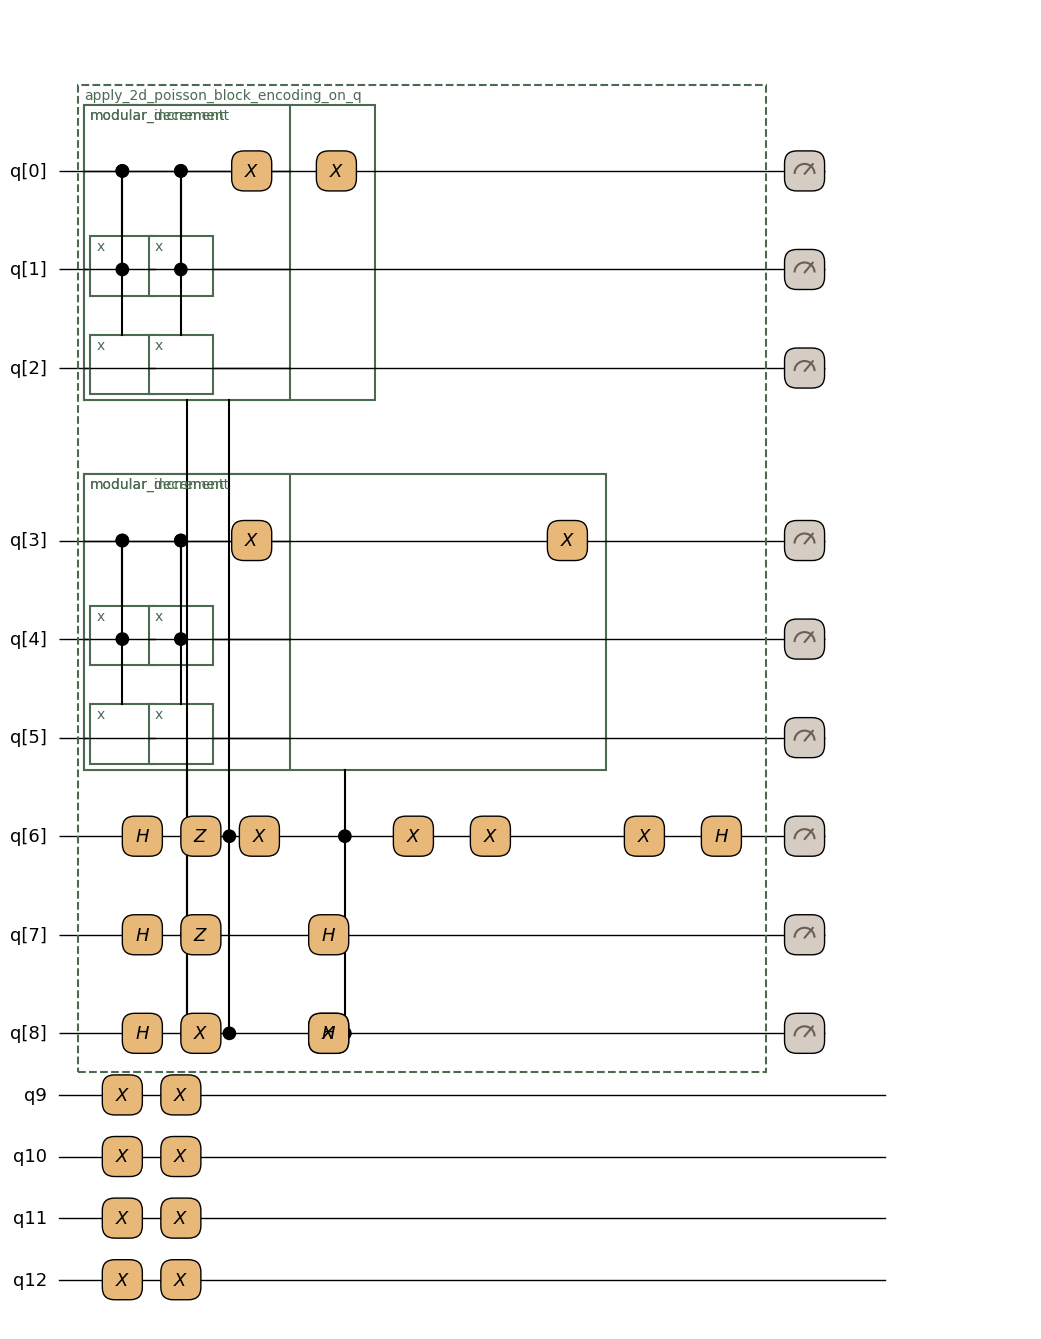

In [37]:
# ============================================================
# 2D block encoding verification
# ============================================================

system_len_2d = n_2d * n_2d # for example, 4 if your grid is 4 x 4

num_axis_2d = int(np.log2(n_2d))
num_system_2d = int(np.log2(system_len_2d))
num_signal_2d = 3

block_encoding_bindings_2d = {
    "num_axis": num_axis_2d,
    "num_system": num_system_2d,
    "total_qubits": num_system_2d + num_signal_2d,
}

full_op_2d = operator_of(
    block_encoding_kernel_2d,
    **block_encoding_bindings_2d,
)

# Top-left block corresponds to signal = |000>
encoded_A2 = full_op_2d[:system_len_2d, :system_len_2d].real * 8.0 / h2**2

print("2D encoding matches target:", np.allclose(encoded_A2, A2, atol=1e-8))
print("2D max abs error:", np.max(np.abs(encoded_A2 - A2)))

block_encoding_kernel_2d.draw(
    fold_loops=False,
    inline=True,
    **block_encoding_bindings_2d,
)

With the 2D block encoding checked, we reuse the same QSVT inverse-polynomial workflow. The Qamomile kernel is converted at the Qiskit backend boundary, and the recovered vector is compared with the classical pseudoinverse solution.


In [38]:
def make_qsvt_poisson_kernel_2d(grid_n, normalized_b, num_phases, num_signal=3):
    """Create the 2D Poisson QSVT kernel for the Kronecker-sum encoding."""
    normalized_b = normalize_state(normalized_b)

    if num_phases <= 0:
        raise ValueError("num_phases must be positive.")

    expected_len = grid_n * grid_n

    if expected_len & (expected_len - 1):
        raise ValueError("The encoded system dimension must be a power of two.")

    if len(normalized_b) != expected_len:
        raise ValueError(
            f"Expected len(normalized_b) == {expected_len}, "
            f"got {len(normalized_b)}."
        )

    num_axis = int(np.log2(grid_n))
    num_system = int(np.log2(expected_len))

    # Extra ancilla for Figure 13.4.
    rpi_aux = num_system + num_signal
    total_qubits = num_system + num_signal + 1

    has_even_tail = (num_phases % 2 == 0)

    if has_even_tail:

        @qmc.qkernel
        def qsvt_poisson_kernel_2d(
            theta: qmc.Vector[qmc.Float],
            half_theta: qmc.Vector[qmc.Float],
            neg_half_theta: qmc.Vector[qmc.Float],
            num_pairs: qmc.UInt,
        ) -> qmc.Vector[qmc.Bit]:
            q = qmc.qubit_array(total_qubits, name="q")

            q[0:num_system] = amplitude_encoding(
                q[0:num_system],
                normalized_b,
            )

            # rpi_aux is already |0>, as required by Figure 13.4.

            for pair in qmc.range(num_pairs):
                even_i = pair + pair
                odd_i = even_i + 1

                # R_Pi(phi_even), two_phi = 2 phi
                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[even_i] + neg_half_theta[even_i],
                )

                q = apply_2d_poisson_block_encoding_on_q(
                    q,
                    num_axis,
                    num_system,
                )

                # R_Pi(phi_odd), two_phi = 2 phi
                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[odd_i] + neg_half_theta[odd_i],
                )

                q = qmc.inverse(apply_2d_poisson_block_encoding_on_q)(
                    q,
                    num_axis,
                    num_system,
                )

            # Even number of phases:
            # R_Pi(phi_tail) -> U -> R_Pi(phi_final)
            tail_i = num_pairs + num_pairs
            final_i = tail_i + 1

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[tail_i] + neg_half_theta[tail_i],
            )

            q = apply_2d_poisson_block_encoding_on_q(
                q,
                num_axis,
                num_system,
            )

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[final_i] + neg_half_theta[final_i],
            )

            return qmc.measure(q)

    else:

        @qmc.qkernel
        def qsvt_poisson_kernel_2d(
            theta: qmc.Vector[qmc.Float],
            half_theta: qmc.Vector[qmc.Float],
            neg_half_theta: qmc.Vector[qmc.Float],
            num_pairs: qmc.UInt,
        ) -> qmc.Vector[qmc.Bit]:
            q = qmc.qubit_array(total_qubits, name="q")

            q[0:num_system] = amplitude_encoding(
                q[0:num_system],
                normalized_b,
            )

            # rpi_aux is already |0>, as required by Figure 13.4.

            for pair in qmc.range(num_pairs):
                even_i = pair + pair
                odd_i = even_i + 1

                # R_Pi(phi_even)
                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[even_i] + neg_half_theta[even_i],
                )

                q = apply_2d_poisson_block_encoding_on_q(
                    q,
                    num_axis,
                    num_system,
                )

                # R_Pi(phi_odd)
                q = apply_RPi_figure_13_4_on_q(
                    q,
                    rpi_aux,
                    num_system,
                    num_signal,
                    neg_half_theta[odd_i] + neg_half_theta[odd_i],
                )

                q = qmc.inverse(apply_2d_poisson_block_encoding_on_q)(
                    q,
                    num_axis,
                    num_system,
                )

            # Final phase.
            final_i = num_pairs + num_pairs

            q = apply_RPi_figure_13_4_on_q(
                q,
                rpi_aux,
                num_system,
                num_signal,
                neg_half_theta[final_i] + neg_half_theta[final_i],
            )

            return qmc.measure(q)

    return qsvt_poisson_kernel_2d


In [39]:
qsvt_kernel_2d = make_qsvt_poisson_kernel_2d(
    n_2d,
    normalized_b2,
    len(phi_qsvt),
    num_signal=3,
)

qsvt_circuit_2d = transpiler.to_circuit(
    qsvt_kernel_2d,
    bindings=qsvt_bindings,
).remove_final_measurements(inplace=False)

In [40]:
psi_2d = Statevector.from_instruction(qsvt_circuit_2d).data
c2 = np.real(psi_2d[:A2.shape[0]])
Ac2 = A2 @ c2
alpha_2d = (Ac2 @ b2) / (Ac2 @ Ac2)
computed_u2 = alpha_2d * c2
residual_2d = np.linalg.norm(A2 @ computed_u2 - b2)

print("Computed u:", computed_u2)
print("Classical u:", u2)
print("fidelity:", fidelity(computed_u2, u2))
print("max abs error:", np.max(np.abs(computed_u2 - u2)))


Computed u: [ 0.00846943  0.00614427  0.00335219  0.00156277  0.00156277  0.00335219
  0.00614427  0.00846943  0.00614427  0.00318852 -0.00026047 -0.00244069
 -0.00244069 -0.00026047  0.00318852  0.00614427  0.00335219 -0.00026047
 -0.00441885 -0.00702811 -0.00702811 -0.00441885 -0.00026047  0.00335219
  0.00156277 -0.00244069 -0.00702811 -0.00989904 -0.00989904 -0.00702811
 -0.00244069  0.00156277  0.00156277 -0.00244069 -0.00702811 -0.00989904
 -0.00989904 -0.00702811 -0.00244069  0.00156277  0.00335219 -0.00026047
 -0.00441885 -0.00702811 -0.00702811 -0.00441885 -0.00026047  0.00335219
  0.00614427  0.00318852 -0.00026047 -0.00244069 -0.00244069 -0.00026047
  0.00318852  0.00614427  0.00846943  0.00614427  0.00335219  0.00156277
  0.00156277  0.00335219  0.00614427  0.00846943]
Classical u: [ 0.00861686  0.00623676  0.0033293   0.00144421  0.00144421  0.0033293
  0.00623676  0.00861686  0.00623676  0.0032739  -0.00024067 -0.00248692
 -0.00248692 -0.00024067  0.0032739   0.00623676  

In [43]:
print_resource_estimate("2D QSVT", qsvt_kernel_2d, qsvt_circuit_2d, qsvt_bindings)

2D QSVT Qamomile resource estimate:
Resource Estimate:
  Qubits: 10
  Gates:
    Total: 34147
    Single-qubit: 28569
    Two-qubit: 62
    Multi-qubit: 5516
    T gates: 0
    Clifford gates: 27648
    Rotation gates: 983
2D QSVT Qiskit resource estimate:
  Qubits: 10
  Depth: 11143
  Gate counts: {'x': 13800, 'h': 6440, 'rz': 920, 'z': 920, 'ry': 63, 'cx': 62, 'shift/subcircuit': 4139}


Finally, we visualize the classical NumPy solution and the QSVT-computed solution side by side on the 2D grid.


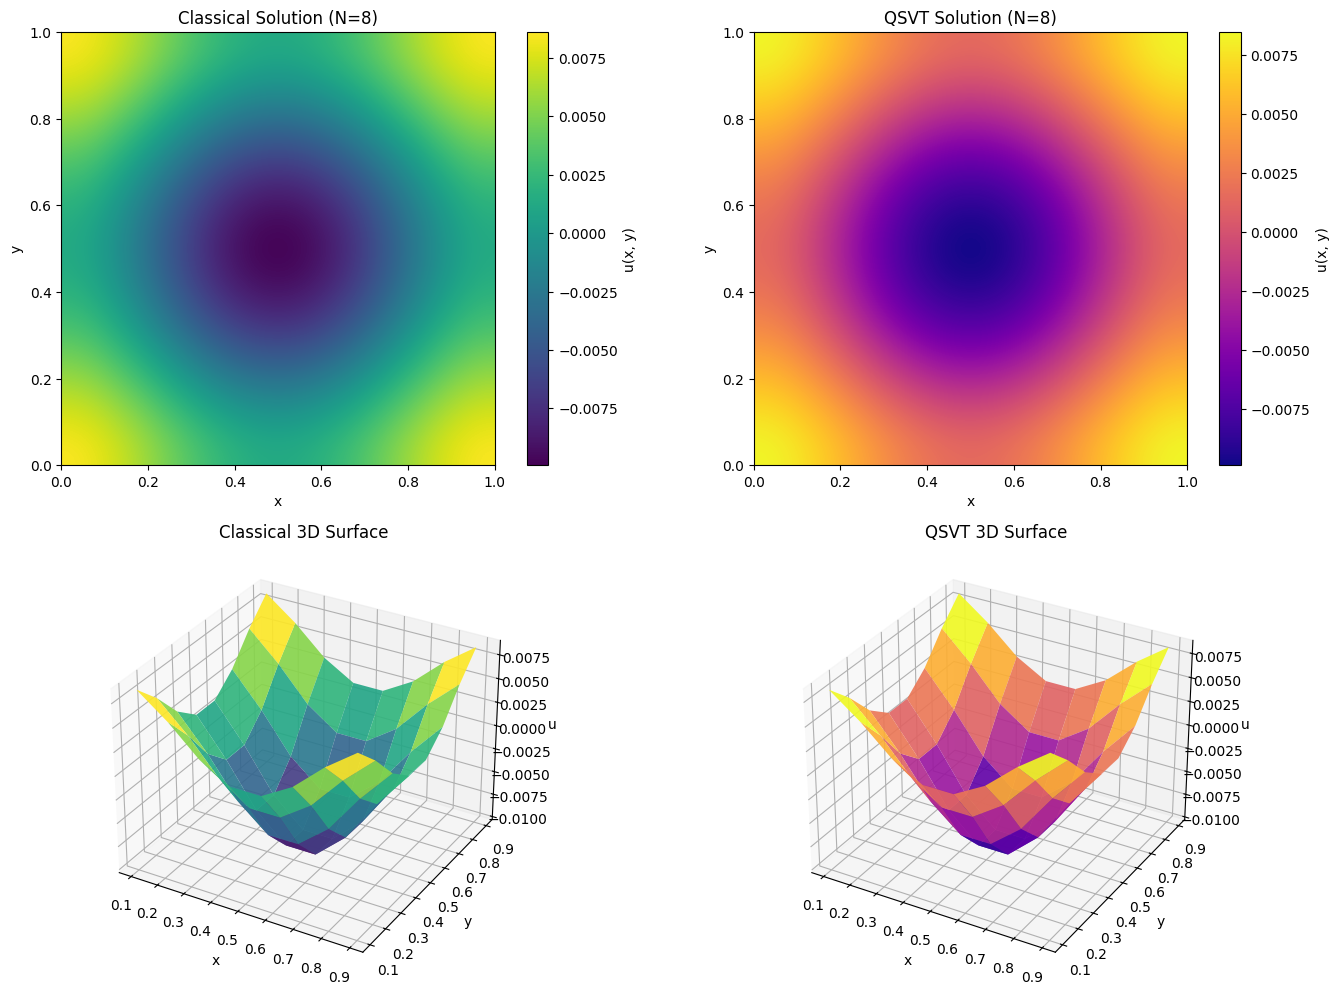

In [41]:
import matplotlib.pyplot as plt

classical_u2 = np.linalg.pinv(A2) @ b2
u_class_grid = classical_u2.reshape((n_2d, n_2d))
u_qsvt_grid = computed_u2.reshape((n_2d, n_2d))

fig = plt.figure(figsize=(14, 10))

# Classical heatmap
ax1 = fig.add_subplot(2, 2, 1)
im1 = ax1.imshow(
    u_class_grid,
    extent=[0, 1, 0, 1],
    origin="lower",
    cmap="viridis",
    interpolation="bicubic",
)
ax1.set_title(f"Classical Solution (N={n_2d})")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(im1, ax=ax1, label="u(x, y)")

# QSVT heatmap
ax2 = fig.add_subplot(2, 2, 2)
im2 = ax2.imshow(
    u_qsvt_grid,
    extent=[0, 1, 0, 1],
    origin="lower",
    cmap="plasma",
    interpolation="bicubic",
)
ax2.set_title(f"QSVT Solution (N={n_2d})")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
fig.colorbar(im2, ax=ax2, label="u(x, y)")

# Classical surface
ax3 = fig.add_subplot(2, 2, 3, projection="3d")
ax3.plot_surface(X2, Y2, u_class_grid, cmap="viridis", edgecolor="none", alpha=0.9)
ax3.set_title("Classical 3D Surface")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("u")

# QSVT surface
ax4 = fig.add_subplot(2, 2, 4, projection="3d")
ax4.plot_surface(X2, Y2, u_qsvt_grid, cmap="plasma", edgecolor="none", alpha=0.9)
ax4.set_title("QSVT 3D Surface")
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_zlabel("u")

plt.tight_layout()
# plt.savefig("qamomile_qsvt_poisson_2d.png", dpi=300, bbox_inches="tight")
plt.show()


## Summary

In this notebook, we:

- Used a second-order finite-difference method to define the 1D and 2D periodic Poisson problems.
- Implemented shift-based LCU block encodings with Qamomile qkernels, using `qmc.modular_increment` and `qmc.modular_decrement` for the cyclic shifts.
- Prepared the source vector with Qamomile's `Möttönen Amplitude Encoding`.
- Applied a QSVT inverse-polynomial phase sequence to find the solution of the 1D and 2D periodic Poisson problems.
- Compared the exact statevector results with classical solutions computed using `NumPy`.

For larger systems, replace the exact `Operator` and `Statevector` checks with backend sampling or resource estimation, because exact simulation scales exponentially.
